In [1]:
# Importing libraries
import os
import sys
import numpy             as np
import pandas            as pd
import seaborn           as sns
import matplotlib        as mpl
import matplotlib.pyplot as plt
from   copy import deepcopy
# Importing custom libraries
sys.path.append("..")
from scripts.util     import *
from scripts.subjects import Subject

In [2]:
# Loading the data-frame
# The dataframe consists of all subject-wise task-related, demographic, and psychometric variables
df = BEHAVIOR.copy()
# Loading the subjects
# Held-Out Cohort
subjects = Subject.get_test_subjects()
print(f"Number of subjects in Held-Out Cohort: {len(subjects)}")
# Filtering the data-frame for only these subjects
data = df[df['subID'].isin(Subject.get_subids(subjects))].copy()
data

Number of subjects in Held-Out Cohort: 36


,subID,age,sex,hand,patient,consumption_score,devaluation_ratio,rate,slope_run_1,slope_run_2,...,STAI_Total,LSPS_Total,AUDIT_Total,EAT_Total,PDSS_Total,PSWQ_Total,BDI_Total,Apath_Total,BISBAS-BIS_Total,BIS_Total
139,190,19.0,0.0,1.0,0.0,10.0,0.559859,2.839537,0.087762,0.000739,...,48.0,47.0,5.0,3.0,0.0,32.0,8.0,51.0,19.0,41.0
140,191,25.0,1.0,1.0,0.0,10.0,1.000000,3.089591,0.042119,0.058324,...,32.0,4.0,1.0,3.0,0.0,33.0,0.0,27.0,18.0,67.0
141,192,24.0,1.0,1.0,0.0,10.0,0.926667,2.702570,0.150604,0.026243,...,39.0,15.0,2.0,4.0,1.0,44.0,10.0,22.0,21.0,72.0
143,195,21.0,0.0,1.0,0.0,10.0,0.944444,1.275176,0.058400,0.050569,...,25.0,23.0,8.0,0.0,0.0,37.0,2.0,33.0,23.0,65.0
149,205,48.0,1.0,1.0,0.0,10.0,1.000000,1.738704,0.007354,-0.117233,...,35.0,53.0,2.0,3.0,0.0,33.0,7.0,29.0,21.0,60.0
150,206,23.0,1.0,1.0,0.0,10.0,0.394089,3.461014,0.214414,0.035087,...,27.0,3.0,3.0,28.0,0.0,24.0,2.0,20.0,14.0,78.0
151,207,25.0,1.0,1.0,0.0,10.0,0.470588,0.505784,-0.054592,0.003464,...,35.0,17.0,6.0,6.0,0.0,40.0,1.0,26.0,20.0,64.0
152,209,19.0,1.0,1.0,0.0,10.0,0.931741,2.730379,0.087690,0.063621,...,30.0,15.0,4.0,5.0,4.0,44.0,2.0,18.0,23.0,72.0
153,210,23.0,0.0,1.0,0.0,10.0,1.000000,2.694347,0.173216,-0.081070,...,27.0,2.0,1.0,3.0,0.0,30.0,0.0,30.0,18.0,65.0
155,214,37.0,0.0,1.0,0.0,10.0,0.513514,1.361177,-0.009423,-0.010181,...,34.0,40.0,5.0,2.0,0.0,37.0,3.0,31.0,17.0,71.0


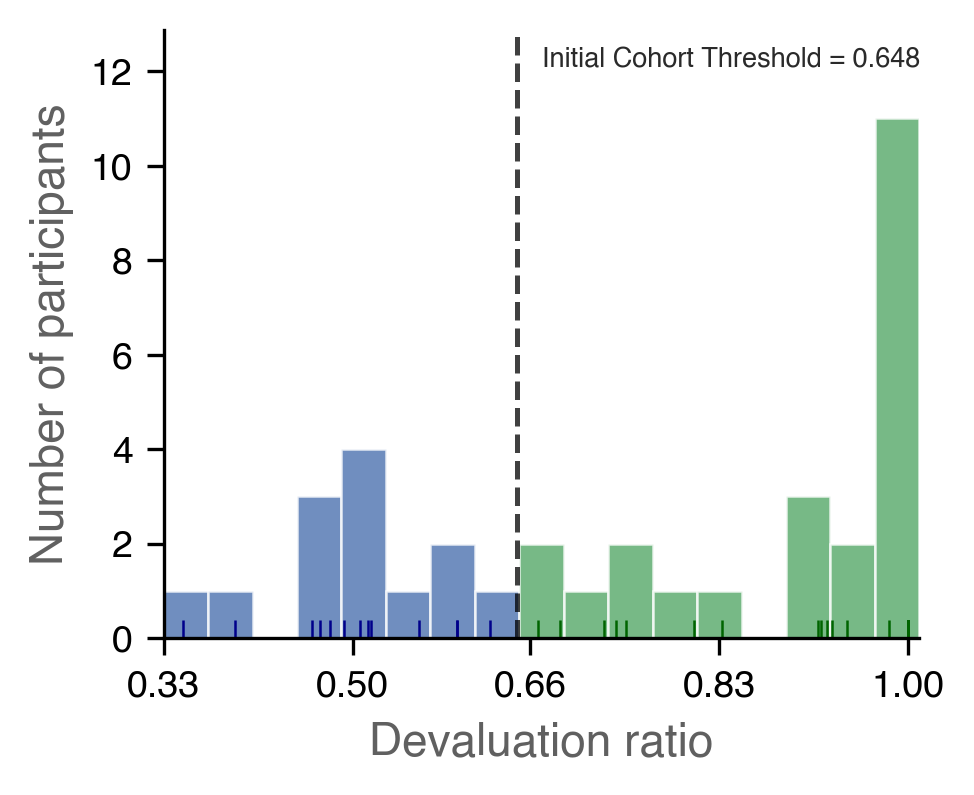

In [3]:
def plot_fig4_panel_a_devaluation_ratio_hist(
    data,
    *,
    FIGURES_DIRECTORY: str,
    cutoff: float = 0.648,
    outname: str = "figure-4_panel-A.png",
) -> tuple[plt.Figure, plt.Axes]:
    dr = data["devaluation_ratio"].to_numpy()

    mpl.rcParams.update({
        "font.family"       : "sans-serif",
        "font.sans-serif"   : ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size"         : 9,
        "axes.labelsize"    : 9,
        "xtick.labelsize"   : 8,
        "ytick.labelsize"   : 8,
        "axes.linewidth"    : 0.8,
        "figure.dpi"        : 300,
        "savefig.dpi"       : 300,
    })

    COLOR_HABIT = "#4C72B0"
    COLOR_GOAL  = "#55A868"
    AXIS_LABEL_COLOR = "#606060"

    fig, ax = plt.subplots(figsize=(3.2, 2.6))

    binwidth   = 0.04
    xmin, xmax = 0.33, 1.01
    bins       = np.arange(xmin, xmax + binwidth, binwidth)

    common_hist_kw = dict(
        bins=bins,
        density=False,
        histtype="bar",
        linewidth=0.6,
    )

    ax.hist(
        dr[dr < cutoff],
        color=COLOR_HABIT,
        alpha=0.8,
        edgecolor="white",
        label="Habitual",
        **common_hist_kw,
    )

    ax.hist(
        dr[dr >= cutoff],
        color=COLOR_GOAL,
        alpha=0.8,
        edgecolor="white",
        label="Goal-directed",
        **common_hist_kw,
    )

    ax.axvline(
        cutoff,
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.75,
        zorder=5,
    )

    try:
        sns.rugplot(
            x=dr[dr < cutoff],
            ax=ax,
            height=0.03,
            color="darkblue",
            linewidth=0.6,
            alpha=1.0,
            zorder=2,
        )
        sns.rugplot(
            x=dr[dr >= cutoff],
            ax=ax,
            height=0.03,
            color="darkgreen",
            linewidth=0.6,
            alpha=1.0,
            zorder=2,
        )
    except Exception:
        pass

    ax.set_xlabel("Devaluation ratio", fontsize=11, color=AXIS_LABEL_COLOR)
    ax.set_ylabel("Number of participants", fontsize=11, color=AXIS_LABEL_COLOR)

    ax.set_xlim(xmin, xmax)
    xticks = [0.33, 0.5, 0.66, 0.83, 1.00]
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{value:.2f}" for value in xticks])

    ax.annotate(
        "Initial Cohort Threshold = 0.648",
        xy=(cutoff, 0.95),
        xycoords=("data", "axes fraction"),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=6.5,
        color="#2A2A2A",
    )

    ax.tick_params(axis="both", width=0.8, length=4, labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout(pad=0.6)

    outpath = os.path.join(FIGURES_DIRECTORY, outname)
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    plt.savefig(outpath, transparent=False)

    return fig, ax


# Example usage:
fig, ax = plot_fig4_panel_a_devaluation_ratio_hist(
    data,
    FIGURES_DIRECTORY=FIGURES_DIRECTORY,
    cutoff=0.648,
)

0.6610799331103677


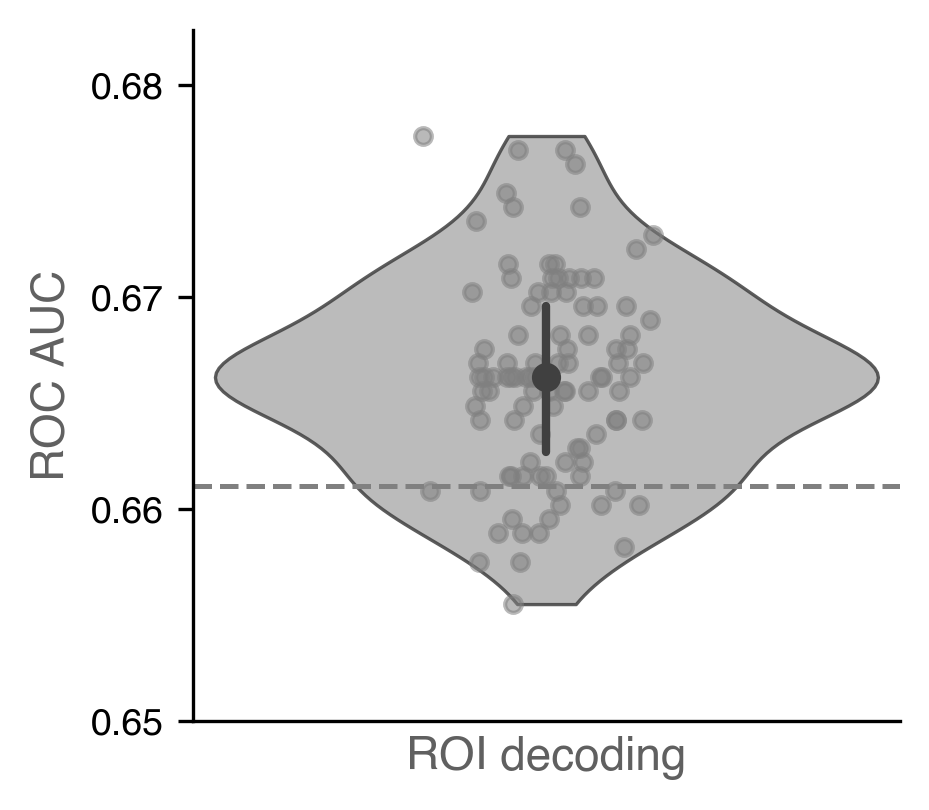

In [4]:
def plot_fig4_panel_b_heldout_roi_decoding(
    *,
    RESULTS_DIRECTORY: str,
    FIGURES_DIRECTORY: str,
    score_relpath: str = os.path.join("ROI_Decoding", "held_out-scores.npy"),
    perm_relpath: str  = os.path.join("ROI_Decoding", "held_out-perm_scores.npy"),
    outname: str = "figure-4_panel-B.png",
) -> tuple[plt.Figure, plt.Axes]:
    score = np.load(os.path.join(RESULTS_DIRECTORY, score_relpath))
    perm  = np.load(os.path.join(RESULTS_DIRECTORY, perm_relpath))

    score = np.mean(score, axis=-1)

    mean_score = score.mean()
    sem_score  = score.std(ddof=1) / np.sqrt(len(score))

    null_95 = np.percentile(perm, 95)
    print(null_95)

    pos = 0.0

    fig, ax = plt.subplots(figsize=(3.0, 2.6), dpi=300)

    parts = ax.violinplot(
        score,
        positions=[0],
        widths=0.75,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor("#B0B0B0")
        pc.set_edgecolor("#404040")
        pc.set_linewidth(0.8)
        pc.set_alpha(0.85)

    rng = np.random.default_rng(0)
    x = rng.normal(0, 0.06, size=len(score))
    ax.scatter(x, score, s=16, color="#808080", alpha=0.55, zorder=2)

    p5, p95 = np.percentile(score, [25, 75])
    mean = np.mean(score)

    ax.plot(
        [pos, pos],
        [p5, p95],
        color="#404040",
        lw=2.0,
        solid_capstyle="round",
        zorder=3,
    )

    ax.scatter(
        [pos],
        [mean],
        s=36,
        color="#404040",
        zorder=4,
    )

    ax.axhline(
        null_95,
        color="#808080",
        linestyle="--",
        linewidth=1.2,
        zorder=1,
    )

    ax.set_xlim(-0.4, 0.4)
    ax.set_xticks([0])
    ax.set_xticklabels(["ROI decoding"], fontsize=11, color="#606060")

    ax.set_ylabel("ROC AUC", fontsize=11, color="#606060")
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", length=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ymin = min(score.min(), null_95) - 0.005
    ymax = max(score.max(), null_95) + 0.005
    ax.set_ylim(ymin, ymax)
    ax.set_yticks([0.65, 0.66, 0.67, 0.68])

    plt.tight_layout(pad=0.4)

    outpath = os.path.join(FIGURES_DIRECTORY, outname)
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    fig.savefig(outpath, bbox_inches="tight", dpi=300)

    return fig, ax


# Example usage:
fig, ax = plot_fig4_panel_b_heldout_roi_decoding(
    RESULTS_DIRECTORY=RESULTS_DIRECTORY,
    FIGURES_DIRECTORY=FIGURES_DIRECTORY,
)